# Riyadh Livability Index (RLI) — Property Search & Recommendation Engine
---
**Project:** Neighborhood DNA — The 15-Minute City Index  
**Input:** `Riyadh_Master_Dataset.csv` — 346K property rows × 27 columns  
**Pipeline:** Filter Properties → Aggregate Survivors → Cluster-Impute → 4-Pillar RLI Score → Rank & Recommend  

$$RLI_i = \left( \sum w_j \hat{x}_{ij} \right) \times \left[ 1 + \frac{H_i}{H_{max}} \right]$$

| Symbol | Meaning |
|---|---|
| $\hat{x}$ | Min-Max scaled features (0–1) |
| $w$ | User-defined or default scientific pillar weights |
| $H$ | Shannon Entropy $-\sum p \ln p$ across 4 pillars |
| $H_{max}$ | $\ln(4)$ — theoretical max diversity for 4 pillars |

### Filter-First Approach
The system follows a strict sequence: **filter properties first, then score neighborhoods.**
1. **Strict Filtering** — Remove all properties that don't match the user's Category, Price, and Room count.
2. **Neighborhood Aggregation** — Group surviving properties by neighborhood.
3. **Scoring** — Apply RLI (Cluster-Imputed + Pillar-Weighted + Entropy-Boosted) only on neighborhoods that have qualifying properties.

## 1 | Setup & Data Loading

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from math import pi

warnings.filterwarnings("ignore")

# ── Dark Theme (matches EDA / Clustering notebooks) ──
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0a0e27',
    'axes.edgecolor': '#2a2f4e',
    'axes.labelcolor': '#c4c7d4',
    'text.color': '#c4c7d4',
    'xtick.color': '#8b8fa3',
    'ytick.color': '#8b8fa3',
    'grid.color': '#1a1f3e',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 120,
    'figure.figsize': (14, 6)
})

GOLD   = '#f0c05a'
CYAN   = '#4fc3f7'
CORAL  = '#ff6b6b'
MINT   = '#66bb6a'
PURPLE = '#ab47bc'
PALETTE = [GOLD, CYAN, CORAL, MINT, PURPLE, '#ff8a65', '#42a5f5', '#ef5350']

EPSILON = 1e-9
H_MAX   = np.log(4)   # ln(4) — theoretical max Shannon entropy for 4 pillars

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Setup complete.')

Setup complete.


In [31]:
# ── Load Master Dataset ──
url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/main/Riyadh_Master_Dataset.csv'

try:
    df_raw = pd.read_csv(url)
    print(f"Loaded from GitHub: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
except:
    df_raw = pd.read_csv('Riyadh_Master_Dataset.csv')
    print(f"Loaded locally: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

print(f"Unique neighborhoods: {df_raw['neighborhood'].nunique()}")
print(f"\nColumns: {df_raw.columns.tolist()}")

# ── Category label map ──
CATEGORY_MAP = {
    1: 'Apartment (Rent)', 2: 'Land', 3: 'Villa', 4: 'Floor (Rent)',
    5: 'Duplex (Rent)', 6: 'Apartment (Sale)', 7: 'Commercial Land',
    8: 'Office', 9: 'Building', 10: 'Compound', 11: 'Farm',
    13: 'Room', 14: 'Shop', 15: 'Warehouse', 16: 'Commercial Building',
    17: 'Tower', 18: 'Camp', 19: 'Parking', 20: 'Studio',
    21: 'Chalet', 22: 'Duplex (Sale)', 23: 'Rest House', 24: 'Palace',
}

# Map category IDs to names for easier filtering in get_recommendations
df_raw['category_name'] = df_raw['category'].map(CATEGORY_MAP)
print(f"Added 'category_name' column to df_raw.")

print(f"\nProperty Categories ({len(CATEGORY_MAP)}):")
for cat_id, label in sorted(CATEGORY_MAP.items()):
    count = (df_raw['category'] == cat_id).sum()
    if count > 0:
        print(f"  {cat_id:>2} → {label:<22s} ({count:>6,} properties)")

df_raw.head(3)

Loaded from GitHub: 348,704 rows × 29 columns
Unique neighborhoods: 176

Columns: ['neighborhood', 'property_id', 'price', 'area', 'category', 'total_rooms', 'lat', 'lng', 'dining_cafe', 'med_facilities', 'health_retail', 'fitness_care', 'edu_primary', 'edu_higher', 'religious', 'essential_retail', 'parks_green', 'sports_play', 'pedestrian', 'resort_rural_retreats', 'gov_civil', 'malls_shopping', 'Fiber_Available', 'FWA_Available', 'Mobile_Available', 'connectivity_score', 'bus_count', 'metro_count', 'neighborhood_area_km2']
Added 'category_name' column to df_raw.

Property Categories (23):
   1 → Apartment (Rent)       (55,010 properties)
   2 → Land                   (81,838 properties)
   3 → Villa                  (124,911 properties)
   4 → Floor (Rent)           ( 8,107 properties)
   5 → Duplex (Rent)          (12,271 properties)
   6 → Apartment (Sale)       (28,910 properties)
   7 → Commercial Land        ( 7,587 properties)
   8 → Office                 ( 3,210 properties)
 

,neighborhood,property_id,price,area,category,total_rooms,lat,lng,dining_cafe,med_facilities,health_retail,fitness_care,edu_primary,edu_higher,religious,essential_retail,parks_green,sports_play,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count,neighborhood_area_km2,category_name
0,2nd Industrial City,1,"4,500.00",160.00,1,6,24.56,46.86,46,2,1,0,1,0,0,7,3,3,0,0,9,4,0.00,1.00,1.00,2.00,53,0,33.71,Apartment (Rent)
1,2nd Industrial City,2,"17,000.00",150.00,1,4,24.55,46.87,46,2,1,0,1,0,0,7,3,3,0,0,9,4,0.00,1.00,1.00,2.00,53,0,33.71,Apartment (Rent)
2,2nd Industrial City,3,"1,500,000.00",750.00,2,0,24.56,46.86,46,2,1,0,1,0,0,7,3,3,0,0,9,4,0.00,1.00,1.00,2.00,53,0,33.71,Land


## 2 | Feature Groups & RLI Pillars
Identical to the scoring notebook — these definitions are reused by the filtering pipeline.

In [32]:
# ── Feature groups ──
PILLAR_COLS = [
    'dining_cafe', 'med_facilities', 'health_retail', 'fitness_care',
    'edu_primary', 'edu_higher', 'religious', 'essential_retail',
    'parks_green', 'sports_play', 'pedestrian', 'resort_rural_retreats',
    'gov_civil', 'malls_shopping'
]
CONNECTIVITY_COLS = ['Fiber_Available', 'FWA_Available', 'Mobile_Available', 'connectivity_score']
TRANSIT_COLS = ['bus_count', 'metro_count']
NEIGH_CONST_COLS = PILLAR_COLS + CONNECTIVITY_COLS + TRANSIT_COLS

# ── 4 RLI Pillars ──
PILLARS = {
    'Core': {
        'weight': 0.40,
        'features': ['med_facilities', 'edu_primary', 'essential_retail', 'religious'],
    },
    'Mobility': {
        'weight': 0.25,
        'features': ['bus_count', 'metro_count', 'pedestrian', 'connectivity_score'],
    },
    'Well-being': {
        'weight': 0.20,
        'features': ['dining_cafe', 'parks_green', 'sports_play', 'fitness_care'],
    },
    'Infrastructure': {
        'weight': 0.15,
        'features': ['Fiber_Available', 'gov_civil', 'malls_shopping', 'edu_higher'],
    },
}

ALL_RLI_FEATURES = sorted({f for p in PILLARS.values() for f in p['features']})
ML_COLS = PILLAR_COLS + CONNECTIVITY_COLS + TRANSIT_COLS + \
          ['property_count', 'median_price', 'median_area', 'n_categories']

print(f"RLI uses {len(ALL_RLI_FEATURES)} features across {len(PILLARS)} pillars:")
for pname, pinfo in PILLARS.items():
    print(f"  {pname:15s} ({pinfo['weight']:.0%}): {pinfo['features']}")

RLI uses 16 features across 4 pillars:
  Core            (40%): ['med_facilities', 'edu_primary', 'essential_retail', 'religious']
  Mobility        (25%): ['bus_count', 'metro_count', 'pedestrian', 'connectivity_score']
  Well-being      (20%): ['dining_cafe', 'parks_green', 'sports_play', 'fitness_care']
  Infrastructure  (15%): ['Fiber_Available', 'gov_civil', 'malls_shopping', 'edu_higher']


## 3 | Baseline Pipeline (Full City)
Run the standard aggregation, clustering, and imputation on **all** 346K properties to build the neighborhood-level service profiles. These imputed service scores are reused for every user search — only the property statistics change per filter.

In [33]:
def compute_rli(df_in, pillar_weights=None):
    """
    Compute Riyadh Livability Index for all neighborhoods.
    Returns (df_result sorted by rank, fitted MinMaxScaler).
    """
    # Use default weights if none provided
    pw = pillar_weights if pillar_weights else {'Core':0.4, 'Mobility':0.25, 'Well-being':0.2, 'Infrastructure':0.15}

    # --- NEW: Log-Scaling Step ---
    # np.log1p handles 0s safely. This makes the ranking more fair.
    df_log = np.log1p(df_in[ALL_RLI_FEATURES])

    # Scale 0 to 1
    scaler = MinMaxScaler()
    df_sc = pd.DataFrame(
        scaler.fit_transform(df_log),
        columns=ALL_RLI_FEATURES,
        index=df_in.index
    )

    # Step 2: Weighted pillar scores (vectorized)
    pillar_scores = {}
    for pname, pinfo in PILLARS.items():
        feats = pinfo['features']
        # Use the updated weights from 'pw' dict
        w = pw[pname]
        pillar_scores[pname] = df_sc[feats].mean(axis=1) * w

    pillar_df = pd.DataFrame(pillar_scores, index=df_in.index)
    weighted_sum = pillar_df.sum(axis=1)

    # Step 3: Shannon Entropy across 4 pillars
    pillar_props = pillar_df.div(pillar_df.sum(axis=1) + EPSILON, axis=0)
    H = -(pillar_props * np.log(pillar_props + EPSILON)).sum(axis=1)

    # Step 4: Diversity multiplier [1 + H/H_max]
    diversity_mult = 1 + (H / H_MAX)

    # Step 5: RLI = weighted_sum × diversity_multiplier
    raw_rli = weighted_sum * diversity_mult

    # Step 6: Final Normalization (0–100 min-max)
    r_min, r_max = raw_rli.min(), raw_rli.max()
    rli_100 = ((raw_rli - r_min) / (r_max - r_min)) * 100

    # Assemble result
    result = df_in.copy()
    for pname in PILLARS:
        result[f'pillar_{pname}'] = pillar_scores[pname].values
    result['H_entropy']      = H.values
    result['diversity_mult'] = diversity_mult.values
    result['raw_rli']        = raw_rli.values
    result['RLI']            = rli_100.round(2).values
    result['rank']           = result['RLI'].rank(ascending=False, method='min').astype(int)

    return result.sort_values('rank'), scaler

# --- 1. City-Wide Aggregation (Ignore Category for now) ---
df_global = df_raw.groupby('neighborhood').agg(
    neighborhood_area_km2=('neighborhood_area_km2', 'first'),
    property_count=('property_id', 'count'), # This creates the 'property_count' column
    price=('price', 'median'),
    lat=('lat', 'mean'),
    lng=('lng', 'mean'),
    # This part handles all your RLI features (schools, parks, etc.)
    **{f: (f, 'mean') for f in ALL_RLI_FEATURES}
)

# 2. APPLY DENSITY FIX: Raw Counts / km2
count_features = [
    'bus_count', 'metro_count', 'dining_cafe', 'med_facilities',
    'edu_primary', 'religious', 'essential_retail', 'parks_green',
    'sports_play', 'malls_shopping'
]

for feat in count_features:
    if feat in df_global.columns:
        # Service Density = Total / Area
        df_global[feat] = df_global[feat] / df_global['neighborhood_area_km2']

# Fill any infinity errors if area was 0
df_global = df_global.replace([np.inf, -np.inf], 0).fillna(0)

print(f"✅ Global Ranking Matrix created: {df_global.shape[0]} neighborhoods.")

# 3. COMPUTE GLOBAL RLI (Standard scientific weights)
# This uses your Shannon Entropy logic to score every neighborhood
df_ranked, _ = compute_rli(df_global) # Unpack the scaler, as it's not used here.

# 4. OUTPUT TO CSV
df_ranked.to_csv('Riyadh_Global_Ranking.csv', index=True)
print("✅ Global Ranking CSV generated successfully.")

# Assign df_imputed and df_full for downstream compatibility based on the new global ranking
df_imputed = df_ranked.copy()
df_full = df_ranked.copy()

✅ Global Ranking Matrix created: 176 neighborhoods.
✅ Global Ranking CSV generated successfully.


## 4 | RLI Scoring Function
Same `compute_rli()` from the scoring notebook — no changes. This is the single source of truth for all scoring.

In [34]:
def compute_rli(df_in, pillar_weights=None):
    """
    Compute Riyadh Livability Index for all neighborhoods.
    Returns (df_result sorted by rank, fitted MinMaxScaler).
    """
    # Use default weights if none provided
    pw = pillar_weights if pillar_weights else {'Core':0.4, 'Mobility':0.25, 'Well-being':0.2, 'Infrastructure':0.15}

    # --- NEW: Log-Scaling Step ---
    # np.log1p handles 0s safely. This makes the ranking more fair.
    df_log = np.log1p(df_in[ALL_RLI_FEATURES])

    # Scale 0 to 1
    scaler = MinMaxScaler()
    df_sc = pd.DataFrame(
        scaler.fit_transform(df_log),
        columns=ALL_RLI_FEATURES,
        index=df_in.index
    )

    # Step 2: Weighted pillar scores (vectorized)
    pillar_scores = {}
    for pname, pinfo in PILLARS.items():
        feats = pinfo['features']
        # Use the updated weights from 'pw' dict
        w = pw[pname]
        pillar_scores[pname] = df_sc[feats].mean(axis=1) * w

    pillar_df = pd.DataFrame(pillar_scores, index=df_in.index)
    weighted_sum = pillar_df.sum(axis=1)

    # Step 3: Shannon Entropy across 4 pillars
    pillar_props = pillar_df.div(pillar_df.sum(axis=1) + EPSILON, axis=0)
    H = -(pillar_props * np.log(pillar_props + EPSILON)).sum(axis=1)

    # Step 4: Diversity multiplier [1 + H/H_max]
    diversity_mult = 1 + (H / H_MAX)

    # Step 5: RLI = weighted_sum × diversity_multiplier
    raw_rli = weighted_sum * diversity_mult

    # Step 6: Final Normalization (0–100 min-max)
    r_min, r_max = raw_rli.min(), raw_rli.max()
    rli_100 = ((raw_rli - r_min) / (r_max - r_min)) * 100

    # Assemble result
    result = df_in.copy()
    for pname in PILLARS:
        result[f'pillar_{pname}'] = pillar_scores[pname].values
    result['H_entropy']      = H.values
    result['diversity_mult'] = diversity_mult.values
    result['raw_rli']        = raw_rli.values
    result['RLI']            = rli_100.round(2).values
    result['rank']           = result['RLI'].rank(ascending=False, method='min').astype(int)

    return result.sort_values('rank'), scaler

print("compute_rli() defined ✓")

compute_rli() defined ✓


def get_smart_recommendation(user_category, max_price, min_rooms=0):
    """
    Filters the pre-calculated Global RLI for specific property availability
    based on user criteria.
    """
    # Load the pre-calculated global scores
    # Ensure 'neighborhood' is set as index if it's saved as a column in the CSV
    df_scores = pd.read_csv('Riyadh_Global_Ranking.csv').set_index('neighborhood')
    
    # 1. CATEGORY FILTER: Find neighborhoods where this property exists
    # We look at the raw dataset for availability
    available_mask = df_raw['category_name'] == user_category
    
    # 2. DYNAMIC ROOM LOGIC: Ignore rooms for Land/Plots
    if user_category not in ['Land', 'Commercial Land', 'Farm']:
        # IMPORTANT: Use 'total_rooms' as per df_raw column name
        available_mask = available_mask & (df_raw['total_rooms'] >= min_rooms)
    
    # 3. BUDGET FILTER
    available_mask = available_mask & (df_raw['price'] <= max_price)
    
    # Get the unique neighborhoods that survived the filters
    eligible_neighborhoods = df_raw[available_mask]['neighborhood'].unique()
    
    # 4. OUTPUT RECOMMENDATION:
    # Take the Global Ranking but ONLY show the eligible neighborhoods
    recommendations = df_scores[df_scores.index.isin(eligible_neighborhoods)]
    
    return recommendations.sort_values('rank')

In [35]:
def property_search(
    df_raw,
    df_global_ranked, # This is your df_ranked from Cell 7
    category_label,   # e.g., 'Villa' or 'Land'
    max_price,
    min_rooms=0
):
    # 1. Start with the Global Ranking (The DNA of Riyadh)
    results = df_global_ranked.copy()

    # 2. Define Category Mask
    mask = df_raw['category_name'] == category_label
    mask &= df_raw['price'] <= max_price

    # 3. THE "LAND" FIX: Only filter rooms if the category physically has them
    # If the category is Land, Farm, or Commercial Land, we skip room filtering
    land_categories = ['Land', 'Commercial Land', 'Farm', 'Rest House']
    if category_label not in land_categories and min_rooms > 0:
        mask &= df_raw['total_rooms'] >= min_rooms

    # 4. Find valid neighborhoods that have these properties
    valid_neighborhoods = df_raw[mask]['neighborhood'].unique()

    # 5. Filter the Global Rankings list to ONLY show these neighborhoods
    # We keep the ORIGINAL 'rank' from the city-wide index
    final_recommendations = results[results.index.isin(valid_neighborhoods)]

    return final_recommendations.sort_values('rank')

## 6 | User Search Simulation
Set your preferences below, then run the cell to see personalized results.

> **How it works:** The system throws away everything that doesn't fit your criteria, then measures "Livability" (parks, schools, transit, etc.) on what's left, and presents neighborhoods that are both **livable AND have the property you want.**

### 6.1 | Define User Preferences

In [36]:
# ═══════════════════════════════════════════════════════════
# ✏️  EDIT THESE VARIABLES TO CHANGE YOUR SEARCH
# ═══════════════════════════════════════════════════════════

user_pref_cat   = 2              # 3 = Villa (see category table above)
user_min_price  = 500_000        # Minimum budget (SAR)
user_max_price  = 2_000_000      # Maximum budget (SAR)
user_min_rooms  = 6              # Minimum rooms (0 = no filter)

# Pillar weights (set to None for defaults: Core 40%, Mobility 25%, Well-being 20%, Infra 15%)
user_weights = None
# user_weights = {'Core': 0.5, 'Mobility': 0.3, 'Well-being': 0.1, 'Infrastructure': 0.1}

# Price compatibility weight (0.0 = ignore price, 1.0 = only price matters)
price_importance = 0.20

# ═══════════════════════════════════════════════════════════

cat_label = CATEGORY_MAP.get(user_pref_cat, f'Category {user_pref_cat}')
print(f"🔍 Search Configuration:")
print(f"   Category:   {cat_label} (code {user_pref_cat})")
print(f"   Budget:     {user_min_price:,.0f} – {user_max_price:,.0f} SAR")
print(f"   Min Rooms:  {user_min_rooms}")
print(f"   Weights:    {'Default (scientific)' if user_weights is None else user_weights}")
print(f"   Price wt:   {price_importance:.0%}")

🔍 Search Configuration:
   Category:   Land (code 2)
   Budget:     500,000 – 2,000,000 SAR
   Min Rooms:  6
   Weights:    Default (scientific)
   Price wt:   20%


### 6.2 | Run Search

In [37]:
# ── Execute the filter-first search ──
df_results = property_search(
    df_raw=df_raw,
    df_global_ranked=df_imputed, # df_imputed holds df_ranked from baseline
    category_label=cat_label,
    max_price=user_max_price,
    min_rooms=user_min_rooms
)

# --- Post-processing to add property-specific stats and combined score ---
# Re-filter df_raw to get the properties that match the user's criteria for statistics
mask_for_stats = df_raw['category_name'] == cat_label
mask_for_stats &= df_raw['price'].between(user_min_price, user_max_price)

land_categories_for_stats = ['Land', 'Commercial Land', 'Farm', 'Rest House']
if cat_label not in land_categories_for_stats and user_min_rooms > 0:
    mask_for_stats &= df_raw['total_rooms'] >= user_min_rooms

filtered_properties_for_stats = df_raw[mask_for_stats]

# Aggregate statistics for the qualifying neighborhoods
neigh_stats_for_results = filtered_properties_for_stats.groupby('neighborhood').agg(
    filtered_count=('property_id', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_area=('area', 'mean'),
    avg_rooms=('total_rooms', 'mean'),
)

# Merge these statistics into df_results
df_results = df_results.join(neigh_stats_for_results, how='inner')

# Recalculate price compatibility score (closer to budget midpoint = better)
budget_mid = (user_min_price + user_max_price) / 2
price_dist = np.abs(df_results['avg_price'] - budget_mid)
price_max_dist = price_dist.max()
if price_max_dist > 0:
    df_results['price_score'] = (1 - price_dist / price_max_dist) * 100
else:
    df_results['price_score'] = 100.0

# Recalculate combined score and match_pct using the defined price_importance
rli_weight = 1 - price_importance
df_results['combined_score'] = (
    df_results['RLI'] * rli_weight +
    df_results['price_score'] * price_importance
).round(2)

top_score = df_results['combined_score'].max()
df_results['match_pct'] = (df_results['combined_score'] / top_score * 100).round(1) if top_score > 0 else 0.0

# Update rank based on combined score
df_results['rank'] = df_results['combined_score'].rank(ascending=False, method='min').astype(int)
df_results = df_results.sort_values('rank')

# ── Search Summary ──
print(f"\n{'═'*70}")
print(f"  Search Summary")
print(f"{'═'*70}")
print(f"  Showing top neighborhoods for {cat_label}")
print(f"  Budget: {user_min_price:,.0f} – {user_max_price:,.0f} SAR")
if user_min_rooms > 0:
    print(f"  Min Rooms: {user_min_rooms}+")
print(f"{'─'*70}")

if len(df_results) == 0:
    print(f"  ⚠️  No properties match your criteria. Try widening your filters.")
else:
    total_properties = len(df_raw)
    properties_after_filter = len(filtered_properties_for_stats)
    neighborhoods_found = len(df_results)
    neighborhoods_eliminated = df_imputed.shape[0] - len(df_results)

    print(f"  {total_properties:,} total properties")
    print(f"  → {properties_after_filter:,} match your filters")
    print(f"  → {neighborhoods_found} neighborhoods qualify")
    print(f"  → {neighborhoods_eliminated} neighborhoods eliminated")
    print(f"{'═'*70}")

    # ── Top 10 Results ──
    print(f"\n  Top 10 Results:")
    print(f"  {'─'*65}")
    for _, r in df_results.head(10).iterrows():
        name = r.name.replace(' Dist.', '') if isinstance(r.name, str) else str(r.name)
        print(f"  #{int(r['rank']):>2}  {name:<25s}  Match={r['match_pct']:>5.1f}%  "\
              f"RLI={r['RLI']:>6.2f}  Avg Price={r['avg_price']:>12,.0f} SAR  "\
              f"({int(r['filtered_count'])} listings)")


══════════════════════════════════════════════════════════════════════
  Search Summary
══════════════════════════════════════════════════════════════════════
  Showing top neighborhoods for Land
  Budget: 500,000 – 2,000,000 SAR
  Min Rooms: 6+
──────────────────────────────────────────────────────────────────────
  348,704 total properties
  → 37,060 match your filters
  → 150 neighborhoods qualify
  → 26 neighborhoods eliminated
══════════════════════════════════════════════════════════════════════

  Top 10 Results:
  ─────────────────────────────────────────────────────────────────
  # 1  Al Dhubbat                 Match=100.0%  RLI= 96.25  Avg Price=   1,482,081 SAR  (58 listings)
  # 2  Al Aziziyah                Match= 99.5%  RLI=100.00  Avg Price=     888,567 SAR  (212 listings)
  # 3  Al Duraihemiyah            Match= 98.0%  RLI= 97.56  Avg Price=     909,531 SAR  (16 listings)
  # 4  West Umm Al Hamam          Match= 95.0%  RLI= 89.40  Avg Price=   1,446,683 SAR  (27 listin

### 6.3 | Results Visualization

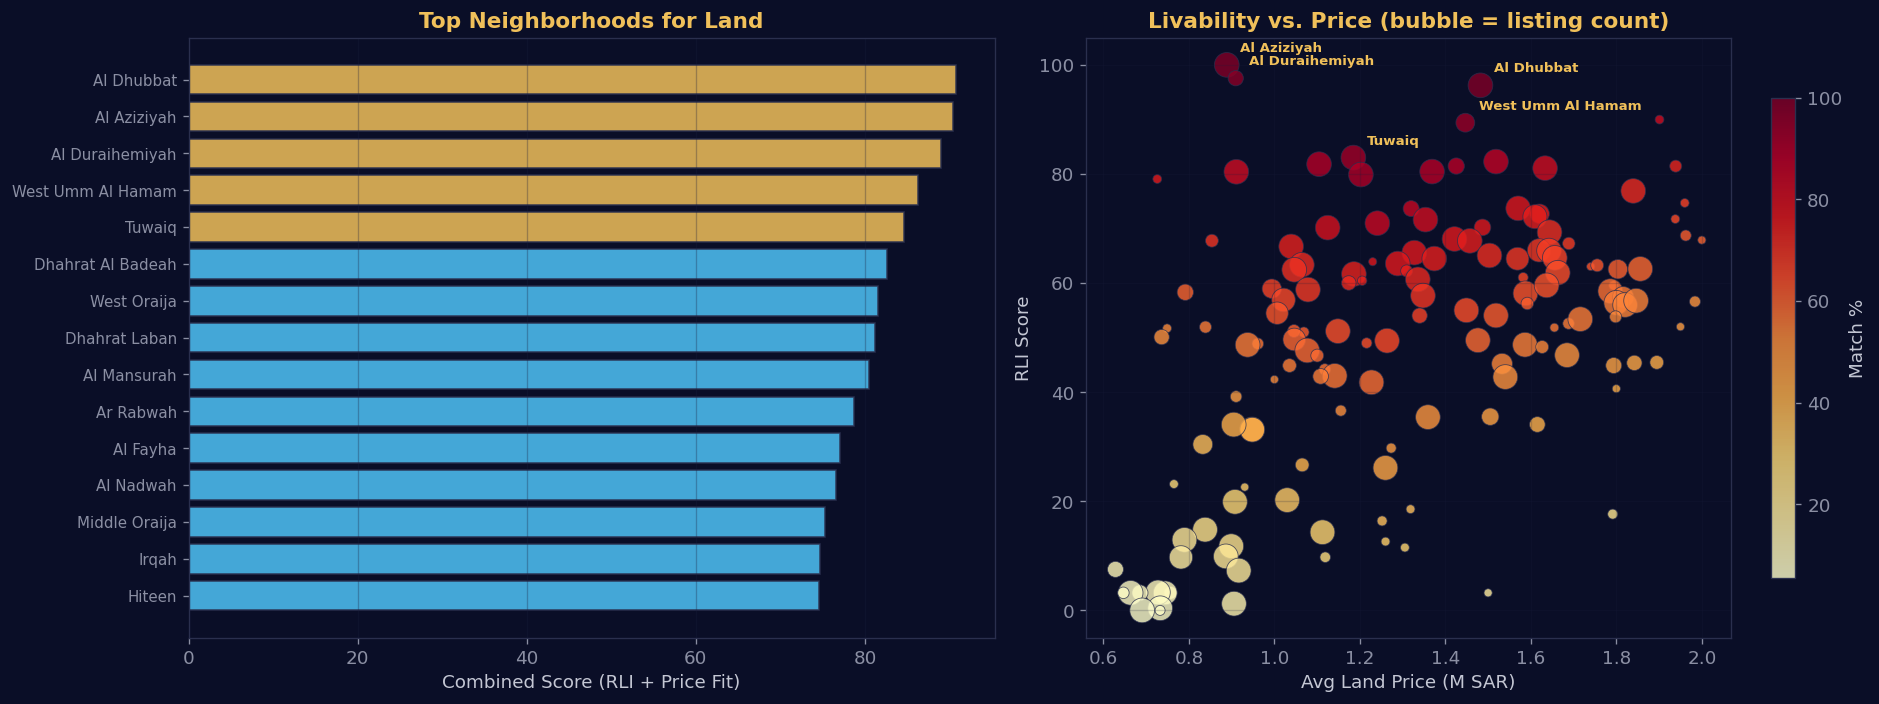

In [38]:
if len(df_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Top 15 by combined score
    ax = axes[0]
    top_n = df_results.head(15).sort_values('combined_score')
    names = [n.replace(' Dist.', '') if isinstance(n, str) else str(n) for n in top_n.index]
    colors = [GOLD if r <= 5 else CYAN for r in top_n['rank']]
    ax.barh(range(len(top_n)), top_n['combined_score'], color=colors, alpha=0.85, edgecolor='#2a2f4e')
    ax.set_yticks(range(len(top_n)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Combined Score (RLI + Price Fit)', fontsize=11)
    ax.set_title(f'Top Neighborhoods for {cat_label}',
                 fontsize=13, fontweight='bold', color=GOLD)
    ax.grid(axis='x', alpha=0.3)

    # Right: RLI vs Avg Price scatter
    ax = axes[1]
    scatter = ax.scatter(
        df_results['avg_price'] / 1e6, df_results['RLI'],
        c=df_results['match_pct'], cmap='YlOrRd',
        s=df_results['filtered_count'].clip(upper=50) * 4 + 20,
        alpha=0.8, edgecolors='#2a2f4e', linewidths=0.5
    )
    # Label top 5
    for _, r in df_results.head(5).iterrows():
        name = r.name.replace(' Dist.', '') if isinstance(r.name, str) else str(r.name)
        ax.annotate(name, (r['avg_price']/1e6, r['RLI']),
                    textcoords='offset points', xytext=(8, 8),
                    fontsize=8, color=GOLD, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Match %', color='#c4c7d4')
    cbar.ax.yaxis.set_tick_params(color='#8b8fa3')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#8b8fa3')
    ax.set_xlabel(f'Avg {cat_label} Price (M SAR)', fontsize=11)
    ax.set_ylabel('RLI Score', fontsize=11)
    ax.set_title('Livability vs. Price (bubble = listing count)',
                 fontsize=13, fontweight='bold', color=GOLD)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

### 6.4 | Top 5 on PCA Scatter

In [39]:
if len(df_results) >= 5 and 'PC1' in df_results.columns:
    fig, ax = plt.subplots(figsize=(13, 9))

    # All neighborhoods (ghost)
    ax.scatter(df_full['PC1'], df_full['PC2'],
               c='#4fc3f7', alpha=0.15, s=20, edgecolors='none', label='All (176)')

    # Qualifying neighborhoods
    qualifying = df_results[df_results['PC1'].notna()]
    ax.scatter(qualifying['PC1'], qualifying['PC2'],
               c=CYAN, alpha=0.5, s=40, edgecolors='#2a2f4e', linewidths=0.5,
               label=f'Qualifying ({len(qualifying)})')

    # Top 5 stars
    top5 = df_results.head(5)
    for i, (idx, r) in enumerate(top5.iterrows()):
        if pd.notna(r.get('PC1')):
            ax.scatter(r['PC1'], r['PC2'], c=PALETTE[i], s=250, zorder=5,
                      edgecolors='white', linewidths=2, marker='*')
            name = idx.replace(' Dist.', '') if isinstance(idx, str) else str(idx)
            ax.annotate(f'{name}\n({r["match_pct"]:.0f}%)',
                        (r['PC1'], r['PC2']),
                        textcoords='offset points', xytext=(12, 12),
                        fontsize=9, color=PALETTE[i], fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=PALETTE[i], lw=1))

    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    ax.set_title(f'Top 5 {cat_label} Matches on PCA Space',
                 fontsize=14, fontweight='bold', color=GOLD)
    ax.axhline(0, color='#2a2f4e', linewidth=0.6)
    ax.axvline(0, color='#2a2f4e', linewidth=0.6)
    ax.legend(fontsize=10, facecolor='#0a0e27', edgecolor='#2a2f4e')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough results for PCA plot.")

Not enough results for PCA plot.


### 6.5 | Pillar Radar — Top 5 Matches

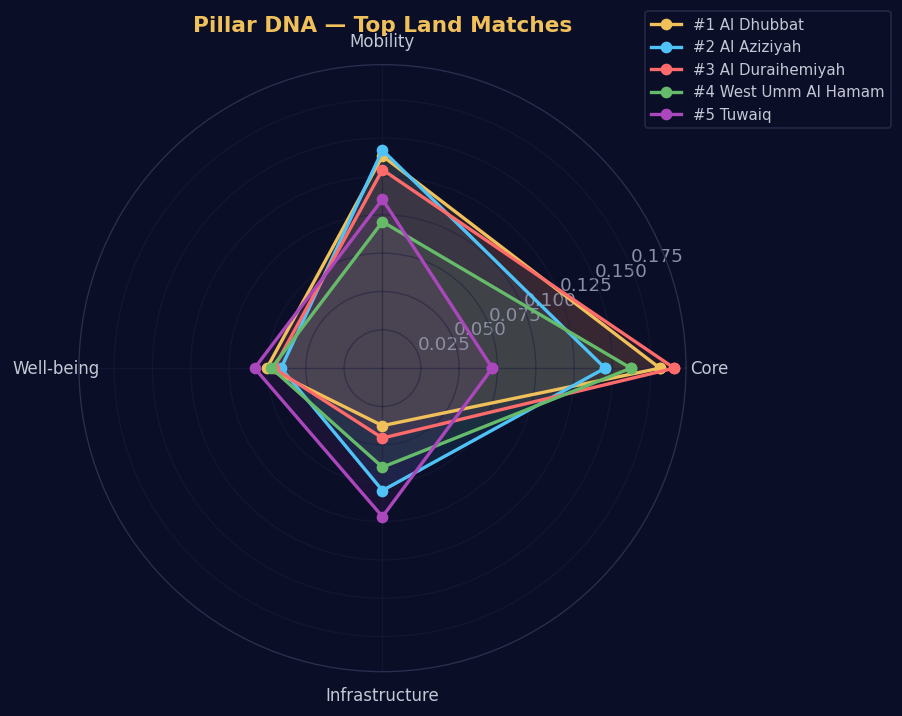

In [40]:
if len(df_results) >= 3:
    top5 = df_results.head(min(5, len(df_results)))
    categories_r = list(PILLARS.keys())
    N = len(categories_r)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.set_facecolor('#0a0e27')

    for i, (idx, row) in enumerate(top5.iterrows()):
        vals = [row[f'pillar_{p}'] for p in categories_r]
        vals += vals[:1]
        name = idx.replace(' Dist.', '') if isinstance(idx, str) else str(idx)
        ax.plot(angles, vals, 'o-', linewidth=2, color=PALETTE[i],
                label=f'#{int(row["rank"])} {name}')
        ax.fill(angles, vals, alpha=0.1, color=PALETTE[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories_r, fontsize=10, color='#c4c7d4')
    ax.set_title(f'Pillar DNA — Top {cat_label} Matches',
                 fontsize=13, fontweight='bold', color=GOLD, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1),
              fontsize=9, facecolor='#0a0e27', edgecolor='#2a2f4e')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough results for radar chart.")

## 7 | Example 2 — Apartment Search (Budget-Conscious)
Different user, different results: searching for affordable apartments with walkability priority.

In [41]:
# --- Apartment search, mobility-heavy ---
# 1. Identify the label from your CATEGORY_MAP
target_label = CATEGORY_MAP[1] # This equals 'Apartment (Rent)'
search_min_price = 10_000
search_max_price = 50_000
search_min_rooms = 3
search_pillar_weights = {'Core': 0.15, 'Mobility': 0.50, 'Well-being': 0.25, 'Infrastructure': 0.10}
search_price_importance = 0.30

# 2. Call the search using the correct parameter names
df_apt = property_search(
    df_raw=df_raw,
    df_global_ranked=df_ranked,  # CHANGED: Use the name from the function def
    category_label=target_label, # CHANGED: Use the label string
    max_price=search_max_price,
    min_rooms=search_min_rooms
)

# --- Post-processing to add property-specific stats and combined score ---
# Re-filter df_raw to get the properties that match the user's criteria for statistics
mask_for_stats_apt = df_raw['category_name'] == target_label
mask_for_stats_apt &= df_raw['price'].between(search_min_price, search_max_price)

land_categories_for_stats = ['Land', 'Commercial Land', 'Farm', 'Rest House']
if target_label not in land_categories_for_stats and search_min_rooms > 0:
    mask_for_stats_apt &= df_raw['total_rooms'] >= search_min_rooms

filtered_properties_for_stats_apt = df_raw[mask_for_stats_apt]

# Aggregate statistics for the qualifying neighborhoods
neigh_stats_for_results_apt = filtered_properties_for_stats_apt.groupby('neighborhood').agg(
    filtered_count=('property_id', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_area=('area', 'mean'),
    avg_rooms=('total_rooms', 'mean'),
)

# Merge these statistics into df_apt
# Use inner join to keep only neighborhoods that have matching properties after filtering
df_apt = df_apt.join(neigh_stats_for_results_apt, how='inner')

# Recalculate price compatibility score (closer to budget midpoint = better)
budget_mid_apt = (search_min_price + search_max_price) / 2
price_dist_apt = np.abs(df_apt['avg_price'] - budget_mid_apt)
price_max_dist_apt = price_dist_apt.max()
if price_max_dist_apt > 0:
    df_apt['price_score'] = (1 - price_dist_apt / price_max_dist_apt) * 100
else:
    df_apt['price_score'] = 100.0

# Recalculate combined score and match_pct using the defined price_importance
rli_weight_apt = 1 - search_price_importance
df_apt['combined_score'] = (
    df_apt['RLI'] * rli_weight_apt +
    df_apt['price_score'] * search_price_importance
).round(2)

top_score_apt = df_apt['combined_score'].max()
df_apt['match_pct'] = (df_apt['combined_score'] / top_score_apt * 100).round(1) if top_score_apt > 0 else 0.0

# Update rank based on combined score
df_apt['rank'] = df_apt['combined_score'].rank(ascending=False, method='min').astype(int)
df_apt = df_apt.sort_values('rank')

cat_label2 = target_label
print(f"\n{'═'*70}")
print(f"  Search: {cat_label2} | {search_min_price:,.0f} – {search_max_price:,.0f} SAR | {search_min_rooms}+ rooms")
print(f"  Weights: Mobility 50%, Well-being 25%, Core 15%, Infra 10%") # This is hardcoded for this example
print(f"{'─'*70}")

if len(df_apt) == 0:
    print(f"  ⚠️  No properties match your criteria. Try widening your filters.")
else:
    total_properties = len(df_raw)
    properties_after_filter = len(filtered_properties_for_stats_apt)
    neighborhoods_found = len(df_apt)
    neighborhoods_eliminated = df_imputed.shape[0] - len(df_apt) # Assuming df_imputed has all neighborhoods

    print(f"  {total_properties:,} total properties")
    print(f"  → {properties_after_filter:,} match your filters")
    print(f"  → {neighborhoods_found} neighborhoods qualify")
    print(f"  → {neighborhoods_eliminated} neighborhoods eliminated")
    print(f"{'═'*70}")

    # ── Top 10 Results ──
    print(f"\n  Top 10 Results:")
    print(f"  {'─'*65}")
    for _, r in df_apt.head(10).iterrows():
        name = r.name.replace(' Dist.', '') if isinstance(r.name, str) else str(r.name)
        print(f"  #{int(r['rank']):>2}  {name:<25s}  Match={r['match_pct']:>5.1f}%  "\
              f"RLI={r['RLI']:>6.2f}  Avg={r['avg_price']:>10,.0f} SAR  "\
              f"({int(r['filtered_count'])} listings)")

df_apt.head()


══════════════════════════════════════════════════════════════════════
  Search: Apartment (Rent) | 10,000 – 50,000 SAR | 3+ rooms
  Weights: Mobility 50%, Well-being 25%, Core 15%, Infra 10%
──────────────────────────────────────────────────────────────────────
  348,704 total properties
  → 27,507 match your filters
  → 157 neighborhoods qualify
  → 19 neighborhoods eliminated
══════════════════════════════════════════════════════════════════════

  Top 10 Results:
  ─────────────────────────────────────────────────────────────────
  # 1  Al Aziziyah                Match=100.0%  RLI=100.00  Avg=    26,170 SAR  (56 listings)
  # 2  Al Dhubbat                 Match= 96.7%  RLI= 96.25  Avg=    34,178 SAR  (59 listings)
  # 3  West Umm Al Hamam          Match= 94.7%  RLI= 89.40  Avg=    32,188 SAR  (57 listings)
  # 4  Al Duraihemiyah            Match= 93.8%  RLI= 97.56  Avg=    36,574 SAR  (15 listings)
  # 5  Dhahrat Al Badeah          Match= 91.1%  RLI= 79.89  Avg=    30,018 SAR  (38

,neighborhood_area_km2,property_count,price,lat,lng,Fiber_Available,bus_count,connectivity_score,dining_cafe,edu_higher,edu_primary,essential_retail,fitness_care,gov_civil,malls_shopping,med_facilities,metro_count,parks_green,pedestrian,religious,sports_play,pillar_Core,pillar_Mobility,pillar_Well-being,pillar_Infrastructure,H_entropy,diversity_mult,raw_rli,RLI,rank,filtered_count,avg_price,median_price,avg_area,avg_rooms,price_score,combined_score,match_pct
neighborhood,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Al Aziziyah Dist.,20.77,1979,"820,000.00",24.59,46.77,1.00,3.51,3.00,8.76,8.00,0.19,1.49,1.00,1.00,0.34,0.77,0.10,0.29,2.00,0.58,0.05,0.15,0.14,0.07,0.08,1.33,1.96,0.85,100.00,1,56,"26,169.64","23,500.00",223.00,5.79,80.85,94.25,100.00
Al Dhubbat Dist.,2.31,361,"270,001.19",24.68,46.72,1.00,4.76,3.00,16.87,0.00,0.00,0.43,0.00,0.00,0.00,5.62,1.30,0.87,0.00,0.87,0.43,0.18,0.14,0.08,0.04,1.25,1.90,0.82,96.25,2,59,"34,177.97","33,000.00",143.02,4.07,79.11,91.11,96.70
West Umm Al Hamam Dist.,3.94,335,"200,000.00",24.69,46.65,1.00,3.55,3.00,15.74,2.00,0.00,1.02,1.00,2.00,0.00,2.79,0.00,0.51,0.00,0.76,0.00,0.16,0.10,0.07,0.06,1.32,1.95,0.77,89.40,3,57,"32,187.72","33,000.00",210.02,4.67,89.06,89.30,94.70
Al Duraihemiyah Dist.,1.69,230,"850,000.00",24.59,46.69,1.00,5.34,3.00,18.39,0.00,0.00,2.97,0.00,1.00,0.00,0.59,0.00,0.00,1.00,1.78,0.59,0.19,0.13,0.07,0.05,1.25,1.90,0.83,97.56,4,15,"36,573.53","38,000.00",164.07,8.13,67.13,88.43,93.80
Dhahrat Al Badeah Dist.,7.46,813,"1,055,600.00",24.59,46.64,1.00,5.49,3.00,10.05,3.00,0.00,1.88,0.00,0.00,0.40,0.27,0.27,0.67,0.00,0.67,0.27,0.12,0.11,0.06,0.06,1.34,1.97,0.70,79.89,5,38,"30,018.42","32,500.00",318.18,5.58,99.91,85.90,91.10


## 8 | Export Results

In [42]:
if len(df_results) > 0:
    export_cols = [
        'rank', 'match_pct', 'combined_score', 'RLI', 'price_score',
        'avg_price', 'median_price', 'filtered_count', 'avg_area', 'avg_rooms',
        'pillar_Core', 'pillar_Mobility', 'pillar_Well-being', 'pillar_Infrastructure',
        'H_entropy', 'km_cluster', 'PC1', 'PC2', 'lat', 'lng',
    ]
    present = [c for c in export_cols if c in df_results.columns]
    df_export = df_results[present].copy()

    fname = f'RLI_Search_{cat_label.replace(" ", "_")}.csv'
    df_export.to_csv(fname)
    print(f"Exported: '{fname}'  ({len(df_export)} neighborhoods × {len(present)} columns)")

    try:
        from google.colab import files
        files.download(fname)
    except ImportError:
        print("(Not in Colab — file saved locally)")
else:
    print("No results to export.")

Exported: 'RLI_Search_Land.csv'  (150 neighborhoods × 17 columns)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9 | Key Findings

### How the Filter-First Pipeline Works
1. **Input:** User specifies category (Villa, Apartment, Land...), price range, and minimum rooms.
2. **Constraint:** System discards every property that doesn't match — only survivors continue.
3. **Analysis:** System measures Livability (parks, schools, transit, fiber, etc.) on the remaining neighborhoods using the pre-computed, cluster-imputed service profiles.
4. **Result:** Neighborhoods are ranked by a **combined score** = RLI × (1 − price_weight) + Price Compatibility × price_weight. The user gets areas that are both **livable AND affordable for their specific property type.**

### What Changed from the Base RLI Notebook
| Aspect | Base RLI | Property Search |
|---|---|---|
| Input scope | All 346K properties | Only properties matching user criteria |
| Neighborhoods scored | All 176 | Only those with qualifying listings |
| Price factor | Not included | Budget-midpoint proximity score |
| Output | City-wide ranking | Personalized, category-specific ranking |
| Service data | Aggregated from all properties | Same imputed profiles (service quality doesn't change per search) |

### API Contract (for FastAPI deployment)
```json
POST /search
{
    "category": 3,
    "min_price": 500000,
    "max_price": 2000000,
    "min_rooms": 6,
    "weights": {"Core": 0.4, "Mobility": 0.25, "Well-being": 0.2, "Infrastructure": 0.15}
}
→ Response: sorted list of neighborhoods with rank, match_pct, avg_price, RLI
```